The input files should first be interpolated onto a common grid in order to compare them

# Imports

In [ ]:
import os
import glob
import numpy as np
import xarray as xr
import cf_xarray as cfxr
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
import io
import math
from PIL import Image, ImageDraw, ImageFont
import numpy as np

from urclimask.urban_areas import UrbanVicinity
from urclimask.utils import (
    kelvin2degC,
    fix_360_longitudes,
)

In [2]:
# pip install papermill

# Variables:

In [3]:
## General configuration

# file = 'tsl_ALPX-3f_ERA5_evaluation_r1i1p1f1_BCCR-UCAN_WRF451R-CI4C_v1-r1_6hr_199901010000-199912311800.nc'
file = 'tas_ALPX-3f_ERA5_evaluation_r1i1p1f1_BCCR-UCAN_WRF451R-CI4C_v1-r1_1hr_199901010000-199912312300.nc'

# City information
city = "Paris"
lon_city = 2.35
lat_city = 48.85

# Root folder where the model data are stored
root_nextcloud = '../I4C_CPRCM_DATA/'

# Path and file name of the official city boundary polygons file
city_polygon_path = '../utils/'
poligon_info_file = 'city_polygons_clean_file.gpkg'

In [4]:
##Information obtained from the file name:
variable, domain, driving_model, scenario, member, institution, model, version, time_interval, time_period = file.split("_")

In [ ]:
## Mask configuration

# Mask parameters
urban_th = 60
urban_sur_th = 15
orog_diff = 100
sftlf_th = 70
ratio_r2u = 1  # Rural cell number per urban one
min_city_size = 80  # Minimum number of grid points required for the city
lon_lim = 0.7
lat_lim = 0.7

domain_resolution = domain.split("-")[1][:-1]  # In km
urban_var = 'sfturf'  # Name of the urban-rural field introduced in the model

file_sfturf = glob.glob(f"{root_nextcloud}{domain}/{institution}/{driving_model}/{scenario}/{member}/{model}/{version}/fx/sfturf/*/*.nc")
file_orog = glob.glob(f"{root_nextcloud}{domain}/{institution}/{driving_model}/{scenario}/{member}/{model}/{version}/fx/orog/*/*.nc")
file_sftlf = glob.glob(f"{root_nextcloud}{domain}/{institution}/{driving_model}/{scenario}/{member}/{model}/{version}/fx/sftlf/*/*.nc")

In [6]:
# List to save figures:
figures = [] 

# Masks obtention

In [7]:
#Folder to save masks
output_dir = '../utils/urclimask_Results'# Name of the output directory
os.makedirs(output_dir, exist_ok = True) #The directory is only created if it does'nt exist

In [8]:
path_name_mask = f"{output_dir}/{city}-{domain}_{model}_urban_rural_mask.nc" #Masks file names

if os.path.isfile(path_name_mask):
    print("The mask already exists")
    urmask = xr.open_dataset(path_name_mask)
else:
    #Open fields datasets
    ds_sfturf = xr.open_dataset(file_sfturf[0])
    ds_orog = xr.open_dataset(file_orog[0])
    ds_sftlf = xr.open_dataset(file_sftlf[0])

    ds_sfturf = fix_360_longitudes(ds_sfturf)#Repository's urclimask function. It's defined in urclimask/utils.py. 
                                            #It converts longitudes from 0–360° to -180–180°
    ds_orog = fix_360_longitudes(ds_orog)
    ds_sftlf = fix_360_longitudes(ds_sftlf)

    #It creates the object urban from UrbanVicinity (urclimask repository)
    URBAN = UrbanVicinity(
        urban_sur_th = urban_sur_th,
        orog_diff = orog_diff,
        sftlf_th = sftlf_th,
        ratio_r2u = ratio_r2u,
        min_city_size = min_city_size,
        lon_city = lon_city,
        lat_city = lat_city,
        lon_lim = lon_lim,
        lat_lim = lat_lim,
        model = model,
        domain = domain,
        urban_th = urban_th,
        urban_var = urban_var
    )

    # Crop area around de city in the fields datasets
    ds_sfturf = URBAN.crop_area_city(ds = ds_sfturf, res = domain_resolution)
    ds_orog = URBAN.crop_area_city(ds = ds_orog, res = domain_resolution)
    ds_sftlf = URBAN.crop_area_city(ds = ds_sftlf, res = domain_resolution)

    # Define masks using the parameters above
    sfturf_mask, sfturf_sur_mask, orog_mask, sftlf_mask = URBAN.define_masks(
        ds_sfturf = ds_sfturf, #
        ds_orog = ds_orog, 
        ds_sftlf = ds_sftlf,
    )

    # sfturf_mask: Urban mask, identifies urban grid cells based on the urban variable (sftimf) and the defined urban threshold (urban_th).
    # sfturf_sur_mask: Urban surroundings mask, identifies grid cells in the transition zone between urban and rural areas based on the urban surface threshold (urban_sur_th).
    # orog_mask: Orography mask, identifies grid cells where the elevation difference is less than the defined threshold (orog_diff). 

    ## Final rural-urban mask:
    # Starting from the city, it progressively expands the surrounding area until it finds enough comparable rural cells, 
    # excluding sea, areas with non-comparable orography, and peri-urban zones.
    urmask = URBAN.select_urban_vicinity(
        sfturf_mask = sfturf_mask, 
        orog_mask = orog_mask,
        sftlf_mask = sftlf_mask,
        sfturf_sur_mask = sfturf_sur_mask
    )
    #ratio_r2u-> Criteria for enough riral cells, predefined (self)

    ##Save the mask in a netcdf file
    urmask.urmask.to_netcdf(path_name_mask)

    print("The file did not exist, so it was calculated and saved.")
    

The mask already exists


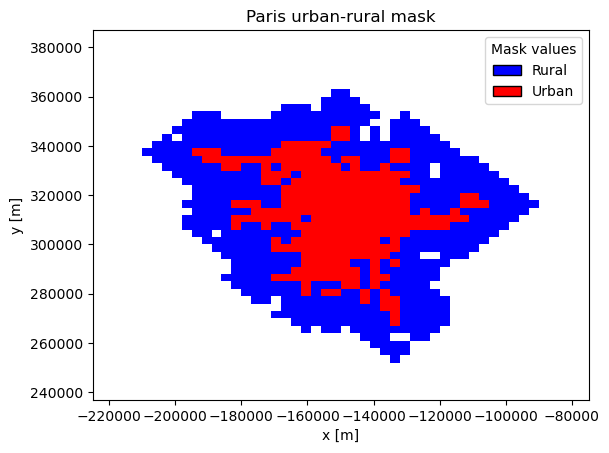

In [9]:
##Mask representation:

#It assign colors to the values
# 0 = rural, 1 = urban
cmap = ListedColormap(["blue", "red"])#Color list definition
norm = BoundaryNorm([-0.5, 0.5, 1.5], cmap.N)#It divide the colorbar into two parts, one for each value (0 and 1

# fig, ax = plt.subplots(figsize=(8, 6))
fig, ax = plt.subplots()

urmask.urmask.plot(ax=ax, cmap=cmap, norm=norm, add_colorbar=False) #It plots the mask without colorbar, with the defined colors

ax.set_title(f"{city} urban-rural mask")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")

# Manual legend with the same colors as the map
legend_elements = [mpatches.Patch(facecolor="blue", edgecolor="black", label="Rural"),
    mpatches.Patch(facecolor="red", edgecolor="black", label="Urban"),]
ax.legend(handles=legend_elements, title="Mask values", loc="upper right")

plt.show()
figures.append(fig)

# Hole year calculations

## Mean heat/humidity island:

In [10]:
#City and rural variable differences: Urban heat islan/ humidity island 

## Mean variable over urban points
urban_mask = urmask.urmask == 1#Urban mask definition

#Find file:
files = glob.glob(f"{root_nextcloud}{domain}/{institution}/{driving_model}/{scenario}/{member}/{model}/{version}/{time_interval}/{variable}/{file}")
if files==[]:#There are some cases where the file is stored in a subfolder
    files = glob.glob(f"{root_nextcloud}{domain}/{institution}/{driving_model}/{scenario}/{member}/{model}/{version}/{time_interval}/{variable}/*/{file}")

#Open file, change units and longitudes
ds = xr.open_dataset(files[0])#because glob.glob return a list of files
ds = kelvin2degC(ds, variable)#K->ºC
ds = fix_360_longitudes(ds)#0–360 -> -180–180

#Selection of urban points and calculation of the mean
variable_city = ds[variable].where(urban_mask)
variable_city_mean = float(variable_city.mean())

## Mean variable over rural points:
urban_mask = urmask.urmask == 0#Rural mask definition
variable_rural = ds[variable].where(urban_mask) #Selection of urban points
variable_rural_mean = float(variable_rural.mean())  #Calculation of the mean

variable_dif = variable_city_mean-variable_rural_mean
print('Difference between the urban mean value and the rural one: ', variable_dif)


Difference between the urban mean value and the rural one:  0.4216184616088867


## Urban and rural variable values with the official city boundary

In [11]:
#City polygon extraction

#Read file
gdf = gpd.read_file(city_polygon_path+poligon_info_file)

# #clean the geopandas file: Only did it onces.
# # Remove \ufeff from colum names
# ucdb_info .columns = [col.lstrip("\ufeff") for col in ucdb_info.columns]
# # Save the clean file:
# ucdb_info .to_file("archivo_limpio.gpkg", driver="GPKG")#to save as geopandas file

#Find the city in the file:
matches = gdf[gdf["GC_UCN_MAI_2025"].astype(str).str.contains(city, case=False, na=False)]
# matches



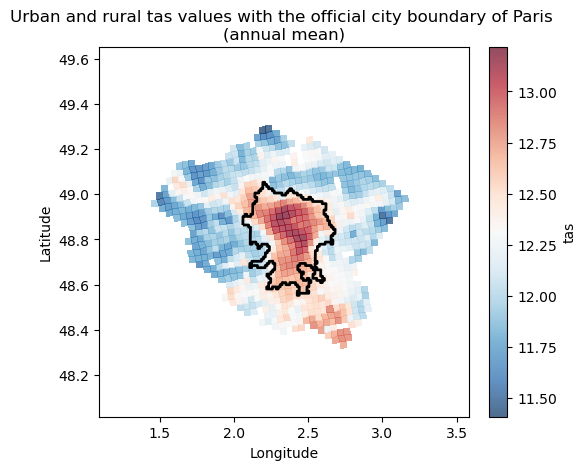

In [12]:
fig, ax = plt.subplots()

urban = variable_city.mean(dim="time")
rural = variable_rural.mean(dim="time")

# Common color limits for both datasets
vmin = np.nanmin([urban.min().item(), rural.min().item()])
vmax = np.nanmax([urban.max().item(), rural.max().item()])

# Same color scale for urban and rural
im1 = ax.pcolormesh(
    urban.lon, urban.lat, urban,
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax,
    alpha=0.7,
    shading="auto",
    zorder=1
)

im2 = ax.pcolormesh(
    rural.lon, rural.lat, rural,
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax,
    alpha=0.7,
    shading="auto",
    zorder=2
)

#Change the geopandas (city polygon) coordinates
matches_lonlat = matches.to_crs("EPSG:4326")
matches_lonlat.boundary.plot(ax=ax, color="black", linewidth=2, zorder=10)

# Una única colorbar común
cbar = plt.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(variable)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Urban and rural {variable} values with the official city boundary of {city} \n(annual mean)")

plt.show()
figures.append(fig)

## Diurnal cicle:

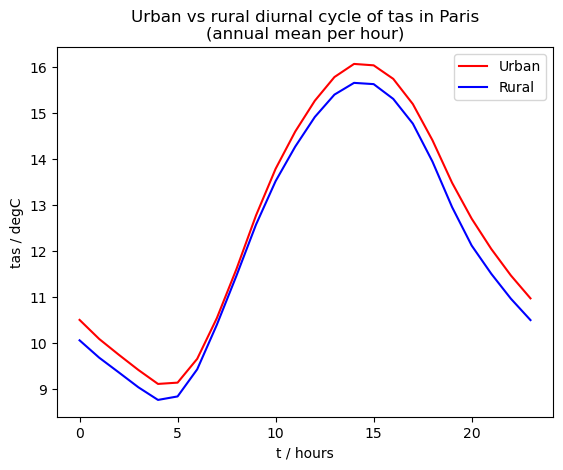

In [13]:
# Function to get the diurnal cycle
def get_diurnal_cycle(var):
    # Promedio espacial
    diurnal_cycle = var.mean(dim='x').mean(dim='y')

    # Transform time to datetime
    diurnal_cycle = diurnal_cycle.assign_coords(
        time=np.array([
            np.datetime64(f"{t.year:04d}-{t.month:02d}-{t.day:02d}T{t.hour:02d}:{t.minute:02d}:{t.second:02d}")
            for t in diurnal_cycle.time.values
        ])
    )

    # Promediate by hour of the day
    diurnal_cycle = diurnal_cycle.groupby('time.hour').mean(dim='time')

    return diurnal_cycle

#Obtention of the diurnal cycle for urban and rural areas
urban_cycle = get_diurnal_cycle(variable_city)
rural_cycle = get_diurnal_cycle(variable_rural)

#Figure
fig, ax = plt.subplots()

urban_cycle.plot(ax=ax, label="Urban", color="red")
rural_cycle.plot(ax=ax, label="Rural", color="blue")

ax.set_title(f"Urban vs rural diurnal cycle of {variable} in {city}\n(annual mean per hour)")
ax.set_xlabel("t / hours")
ax.set_ylabel(f"{variable} / {urban_cycle.attrs['units']}")
ax.legend()

figures.append(fig)
plt.show()


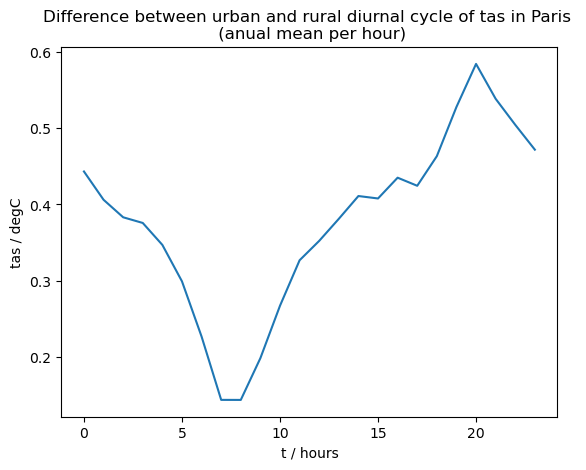

In [14]:
##DIFFERENCE BETWEEN URBAN AND RURAL DIURNAL CICLE:
diurnal_cycle_diff=urban_cycle-rural_cycle
diurnal_cycle_diff.plot()
plt.title(f"Difference between urban and rural diurnal cycle of {variable} in {city} \n (anual mean per hour)")
plt.xlabel('t / hours')
plt.ylabel(f"{variable} / {urban_cycle.attrs['units']}")
figures.append(plt.gcf())

# Summer: heat/hummidity island and diurnal cycles:

In [15]:
## Obtain the summer months:

# Transform time to datetime the date coordinate
variable_city = variable_city.assign_coords(
    time=np.array([
        np.datetime64(f"{t.year:04d}-{t.month:02d}-{t.day:02d}T{t.hour:02d}:{t.minute:02d}:{t.second:02d}")
        for t in variable_city.time.values]))

variable_rural = variable_rural.assign_coords(
    time=np.array([
        np.datetime64(f"{t.year:04d}-{t.month:02d}-{t.day:02d}T{t.hour:02d}:{t.minute:02d}:{t.second:02d}")
        for t in variable_rural.time.values]))

#Obtain the summer months (June, July, August)
summer_months = [6, 7, 8]
summer_variable_city = variable_city.sel(time=variable_city.time.dt.month.isin(summer_months))
summer_variable_rural = variable_rural.sel(time=variable_rural.time.dt.month.isin(summer_months))

In [16]:
#City and rural variable differences: Urban heat islan/ humidity island 
summer_variable_city_mean = float(summer_variable_city.mean())
summer_variable_rural_mean = float(summer_variable_rural.mean())  
summer_variable_dif = summer_variable_city_mean - summer_variable_rural_mean
print('Difference between the urban mean value and the rural one in summer (JJA): ', summer_variable_dif)

Difference between the urban mean value and the rural one in summer (JJA):  0.5374031066894531


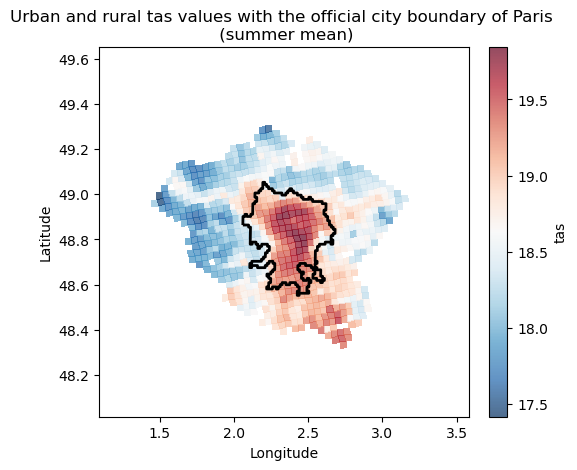

In [17]:
# Rural and urban data for summer months with the official city boundary:
fig, ax = plt.subplots()

summer_urban = summer_variable_city.mean(dim="time")
summer_rural = summer_variable_rural.mean(dim="time")

# Common color limits for both datasets
vmin = np.nanmin([summer_urban.min().item(), summer_rural.min().item()])
vmax = np.nanmax([summer_urban.max().item(), summer_rural.max().item()])

# Same color scale for urban and rural
im1 = ax.pcolormesh(
    summer_urban.lon, summer_urban.lat, summer_urban,
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax,
    alpha=0.7,
    shading="auto",
    zorder=1
)

im2 = ax.pcolormesh(
    summer_rural.lon, summer_rural.lat, summer_rural,
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax,
    alpha=0.7,
    shading="auto",
    zorder=2
)

#Change the geopandas (city polygon) coordinates
# matches_lonlat = matches.to_crs("EPSG:4326")
matches_lonlat.boundary.plot(ax=ax, color="black", linewidth=2, zorder=10)

# Common colorbar
cbar = plt.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(variable)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Urban and rural {variable} values with the official city boundary of {city} \n (summer mean)")
figures.append(fig)

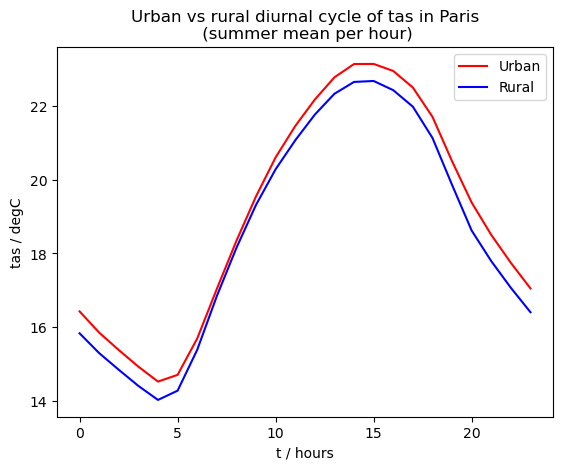

In [18]:
# Function to get the diurnal cycle
def get_diurnal_cycle(var):
    # Promedio espacial
    diurnal_cycle = var.mean(dim='x').mean(dim='y')

    # # Transform time to datetime
    # diurnal_cycle = diurnal_cycle.assign_coords(
    #     time=np.array([
    #         np.datetime64(f"{t.year:04d}-{t.month:02d}-{t.day:02d}T{t.hour:02d}:{t.minute:02d}:{t.second:02d}")
    #         for t in diurnal_cycle.time.values
    #     ])
    

    # Promediate by hour of the day
    diurnal_cycle = diurnal_cycle.groupby('time.hour').mean(dim='time')

    return diurnal_cycle

#Obtention of the diurnal cycle for urban and rural areas
summer_urban_cycle = get_diurnal_cycle(summer_variable_city)
summer_rural_cycle = get_diurnal_cycle(summer_variable_rural)

#Figure
fig, ax = plt.subplots()

summer_urban_cycle.plot(ax=ax, label="Urban", color="red")
summer_rural_cycle.plot(ax=ax, label="Rural", color="blue")

ax.set_title(f"Urban vs rural diurnal cycle of {variable} in {city}\n (summer mean per hour)")
ax.set_xlabel("t / hours")
ax.set_ylabel(f"{variable} / {summer_urban_cycle.attrs['units']}")
ax.legend()

figures.append(fig)
plt.show()


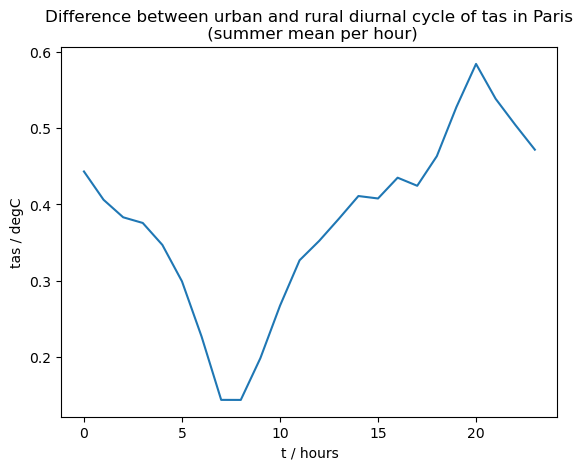

In [19]:
##DIFFERENCE BETWEEN URBAN AND RURAL DIURNAL CICLE:
diurnal_cycle_diff=urban_cycle-rural_cycle
diurnal_cycle_diff.plot()
plt.title(f"Difference between urban and rural diurnal cycle of {variable} in {city}\n (summer mean per hour)")
plt.xlabel('t / hours')
plt.ylabel(f"{variable} / {urban_cycle.attrs['units']}")
figures.append(plt.gcf())

# Summer minimum variable:  heat/hummidity island and diurnal cycles

In [20]:
def get_daily_min_fields(datarray):#summer_variable_rural
    # Spatial mean at each time
    spatial_mean = datarray.mean(dim=("x", "y"))

    # Index position of the minimum within each day
    idx_min_daily = spatial_mean.resample(time="1D").reduce(np.argmin, dim="time")# Group data by day and find the index of the minimum value within each group

    # Select those times from each daily group
    daily_min_fields = []

    for day, idx in zip(idx_min_daily.time.values, idx_min_daily.values):
        day_data = datarray.sel(time=str(day)[:10])# str(day)[:10] takes only the date from the datetime
        daily_min_fields.append(day_data.isel(time=int(idx)))#It saves only the data with times corresponding to day_data

    daily_min_fields = xr.concat(daily_min_fields, dim="time")#It joins alla the save information in a single xarray dataset
    return daily_min_fields
if variable == 'tas':
    #If the variable is temperature, we calculate the daily minimum fields for urban and rural areas in summer
    var_min_summer_variable_rural = get_daily_min_fields(summer_variable_rural)
    var_min_summer_variable_city = get_daily_min_fields(summer_variable_city)
elif variable == 'huss':
    #If the variable is humidity, we select the temperature at 12:00 AM
    var_min_summer_variable_rural = summer_variable_rural.sel(time=summer_variable_rural.time.dt.hour == 0)
    var_min_summer_variable_city = summer_variable_city.sel(time=summer_variable_city.time.dt.hour == 0)


In [21]:
#City and rural variable differences: Urban heat islan/ humidity island 
var_min_summer_variable_city_mean = float(var_min_summer_variable_city.mean())
var_min_summer_variable_rural_mean = float(var_min_summer_variable_rural.mean())  
var_min_summer_variable_dif = var_min_summer_variable_city_mean - var_min_summer_variable_rural_mean
print('Difference between the urban mean value and the rural one in summer (JJA): ', var_min_summer_variable_dif)

Difference between the urban mean value and the rural one in summer (JJA):  0.5664119720458984


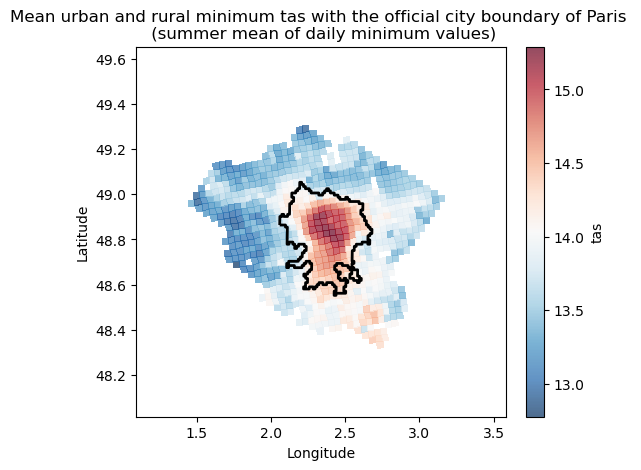

In [22]:
# Rural and urban data for summer months with the official city boundary:
fig, ax = plt.subplots()

var_min_summer_urban = var_min_summer_variable_city.mean(dim="time")
var_min_summer_rural = var_min_summer_variable_rural.mean(dim="time")

# Common color limits for both datasets
vmin = np.nanmin([var_min_summer_urban.min().item(), var_min_summer_rural.min().item()])
vmax = np.nanmax([var_min_summer_urban.max().item(), var_min_summer_rural.max().item()])

# Same color scale for urban and rural
im1 = ax.pcolormesh(
    var_min_summer_urban.lon, var_min_summer_urban.lat, var_min_summer_urban,
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax,
    alpha=0.7,
    shading="auto",
    zorder=1
)

im2 = ax.pcolormesh(
    var_min_summer_rural.lon, var_min_summer_rural.lat, var_min_summer_rural,
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax,
    alpha=0.7,
    shading="auto",
    zorder=2
)

#Plot the city boundary
matches_lonlat.boundary.plot(ax=ax, color="black", linewidth=2, zorder=10)

# Common colorbar
cbar = plt.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(variable)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Mean urban and rural minimum {variable} with the official city boundary of {city} \n (summer mean of daily minimum values)")

plt.show()
figures.append(fig)

There isn`t diurnal cycle for the minimum values

# Save figures

In [33]:
## Save all figures in a single image: 

images = []

# Convert each matplotlib figure to an image
for fig in figures:
    # Avoid empty figures
    if len(fig.axes) == 0:
        continue

    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=300, bbox_inches="tight")
    buf.seek(0)
    images.append(Image.open(buf).convert("RGB"))

# Grid dimensions
ncols = 2
nrows = math.ceil(len(images) / ncols)

# cell size calculation
cell_width = max(img.width for img in images)
cell_height = max(img.height for img in images)

# Create a new blank image to hold the grid
combined = Image.new(
    "RGB",
    (ncols * cell_width, nrows * cell_height),
    "white"
)

# Stick each image in the corresponding cell
for idx, img in enumerate(images):
    row = idx // ncols
    col = idx % ncols

    x = col * cell_width
    y = row * cell_height

    combined.paste(img, (x, y))

#-------------------------------------------------------

# # Example values of the urban heat island
# # Replace these variables with the real ones from your code
# # uhi_annual = annual_uhi
# # uhi_summer = summer_uhi
# # uhi_summer_min = summer_daily_min_uhi

# # File name
# base_name = file.split(".")[0]

# # Text to add
# info_text = (
#     f"File: {file}\n"
#     f"Urban Heat/Humidity Island values:\n"
#     f" - Annual mean: {variable_dif:.2f}\n"
#     f" - Summer mean: {summer_variable_dif:.2f}\n"
#     f" - Summer mean daily minimum: {var_min_summer_variable_dif:.2f}"
# )

# # Height of the text area
# text_height = 350

# # Create a new image with extra space at the bottom
# combined_with_text = Image.new(
#     "RGB",
#     (combined.width, combined.height + text_height),
#     "white"
# )

# # Paste the combined figure in the upper part
# combined_with_text.paste(combined, (0, 0))

# # Draw the text
# draw = ImageDraw.Draw(combined_with_text)

# try:
#     font = ImageFont.truetype("DejaVuSans.ttf", 70)
# except:
#     font = ImageFont.load_default()

# draw.multiline_text(
#     (20, combined.height + 20),   # x, y
#     info_text,
#     fill="black",
#     font=font,
#     spacing=8
# )

# # Replace combined by the new image
# combined = combined_with_text


from PIL import Image, ImageDraw, ImageFont
from matplotlib import font_manager
import textwrap

base_name = file.split(".")[0]

info_text = (
    f"File: {file}\n"
    f"Urban Heat/Humidity Island values:\n"
    f" - Annual mean: {variable_dif:.2f}\n"
    f" - Summer mean: {summer_variable_dif:.2f}\n"
    f" - Summer mean daily minimum: {var_min_summer_variable_dif:.2f}"
)

# Find a real font file
font_path = font_manager.findfont("DejaVu Sans")

# Increase this number if you still want larger text
font_size = 60
font = ImageFont.truetype(font_path, font_size)

# Margins and spacing
margin = 60
spacing = 25

# Compute required text box height automatically
tmp_img = Image.new("RGB", (combined.width, 1), "white")
tmp_draw = ImageDraw.Draw(tmp_img)

bbox = tmp_draw.multiline_textbbox(
    (0, 0),
    info_text,
    font=font,
    spacing=spacing
)

text_height = (bbox[3] - bbox[1]) + 2 * margin

# Create new image with extra space at the bottom
combined_with_text = Image.new(
    "RGB",
    (combined.width, combined.height + text_height),
    "white"
)

# Paste original combined figure
combined_with_text.paste(combined, (0, 0))

# Draw text
draw = ImageDraw.Draw(combined_with_text)

draw.multiline_text(
    (margin, combined.height + margin),
    info_text,
    fill="black",
    font=font,
    spacing=spacing
)

combined = combined_with_text
#------------------------------------------------------

# Save final image
base_name = file.split(".")[0]
output_path = output_dir2 + f"/{base_name}_urban_rural_mask_and_diurnal_cycle.png"
combined.save(output_path)

#Folder to save figures
output_dir2 = f"../utils/urban_rural_mask_and_diurnal_cycle_figures/{domain}/{institution}/{driving_model}/{scenario}/{member}/{model}/{version}"
os.makedirs(output_dir2, exist_ok = True) #The directory is only created if it does'nt exist

In [24]:
figures

[<Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 2 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 2 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 2 Axes>]